<a href="https://colab.research.google.com/github/hemantborse/Capstone/blob/main/Credit_Card_Fraud_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve, auc
import time
import seaborn as sns


This dataset is from https://www.kaggle.com/code/gpreda/credit-card-fraud-detection-predictive-models

Dataset Information copied from Kaggle -

The datasets contains transactions made by credit cards in September 2013 by european cardholders. This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation.

Due to confidentiality issues, there are not provided the original features and more background information about the data.

Features V1, V2, ... V28 are the principal components obtained with PCA;
The only features which have not been transformed with PCA are Time and Amount. Feature Time contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature Amount is the transaction Amount, this feature can be used for example-dependant cost-senstive learning.
Feature Class is the response variable and it takes value 1 in case of fraud and 0 otherwise.

In [158]:
df = pd.read_csv('data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Understanding the Features:**
Features V1, V2, ... V28 are the principal components obtained with PCA; The only features which have not been transformed with PCA are Time and Amount. Feature Time contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature Amount is the transaction Amount, this feature can be used for example-dependant cost-senstive learning. Feature Class is the response variable and it takes value 1 in case of fraud and 0 otherwise.


use CRISP DM Model for this assignment


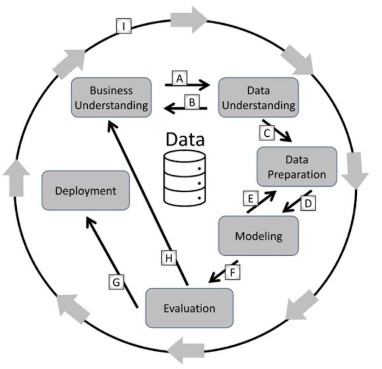

# ============================================================
# PHASE 1: Business Understanding
# ============================================================
# Goal: Detect fraud with maximum recall (≥90%)
# Primary metric: PR-AUC
# Secondary metric: Recall (fraud class)

# ============================================================
# PHASE 2: Data Understanding
# ============================================================


In [159]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [161]:
print(df.isna().sum())
df.dropna()
print(df.isna().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


**Business understanding:** The datasets contains transactions made by credit cards, where we have 492 frauds out of 284,807 transactions.We need to train a model which can predict card fraud

In [162]:
#check duplicates : Identify and remove redundant rows that can skew analysis.
df.duplicated().sum()
df.drop_duplicates()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


# **Exploratory Data Analysis**


1.   **Class Imbalance Barchart**



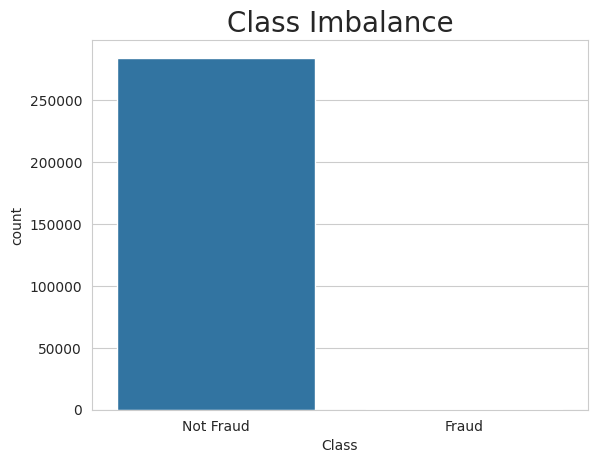

In [163]:
#
sns.countplot(x = 'Class', data = df)
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.title('Class Imbalance', fontsize = 20)
plt.show()

**2.   Scatter Plot Amount Vs Fraud**






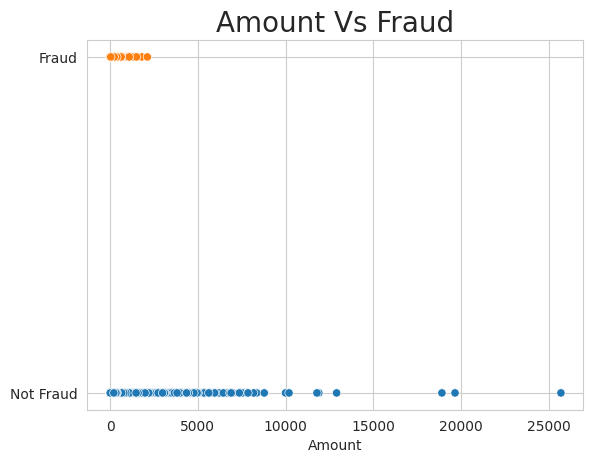

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [164]:
y = np.where(df['Class'] == 1, 1, 0)
sns.scatterplot(data = df, x = 'Amount', y =y, hue =y, legend = False)
plt.yticks([0, 1], ['Not Fraud', 'Fraud']);
plt.title('Amount Vs Fraud', fontsize = 20)
plt.show()
fraud_stats = df.groupby('Class')['Amount'].describe()
print(fraud_stats)

**Observation** :
Based on scatter plot above we can see that fraudulant transactions amount is always less than 5000,
 it's also true of 99% of legit transactions

3. Based on above scatterplot lets explore transaction amount destribution by class





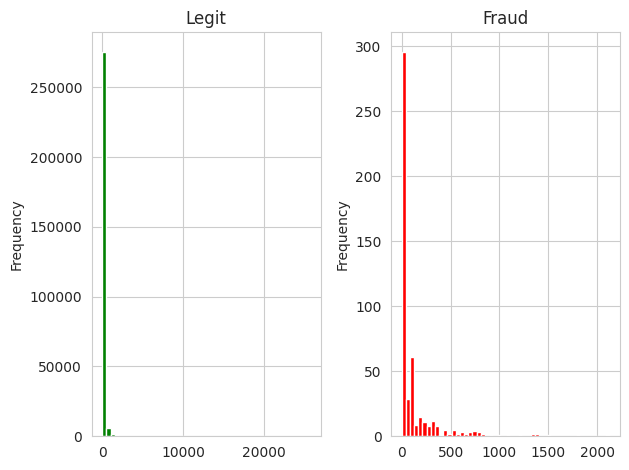

In [165]:

fig,axes = plt.subplots(1,2)
df[df['Class']==0]['Amount'].plot(kind='hist',bins=50,ax=axes[0],title='Legit',color = 'green')
df[df['Class']==1]['Amount'].plot(kind='hist',bins=50,ax=axes[1],title='Fraud',color='red')
plt.tight_layout() #Automatically adjusts subplots so that titles and axis labels do not overlap.
plt.show()

4. Lets explore transaction time destribution by class

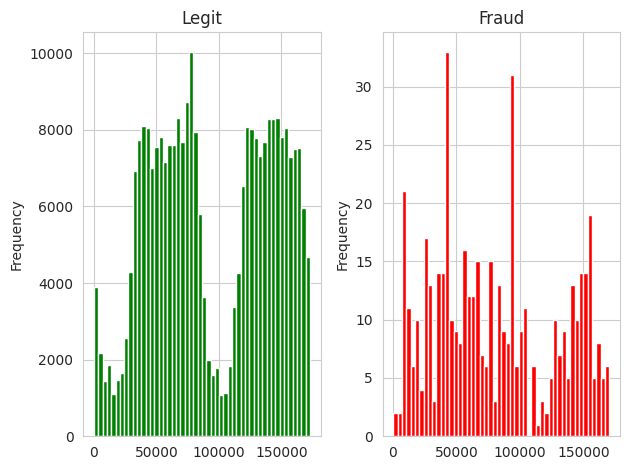

In [166]:

fig,axes = plt.subplots(1,2)
df[df['Class']==0]['Time'].plot(kind='hist',bins=50,ax=axes[0],title='Legit',color = 'green')
df[df['Class']==1]['Time'].plot(kind='hist',bins=50,ax=axes[1],title='Fraud',color='red')
plt.tight_layout()
plt.show()

5. Lets explore Box Plots for V1 to V28 (Fraud Vs Legit)

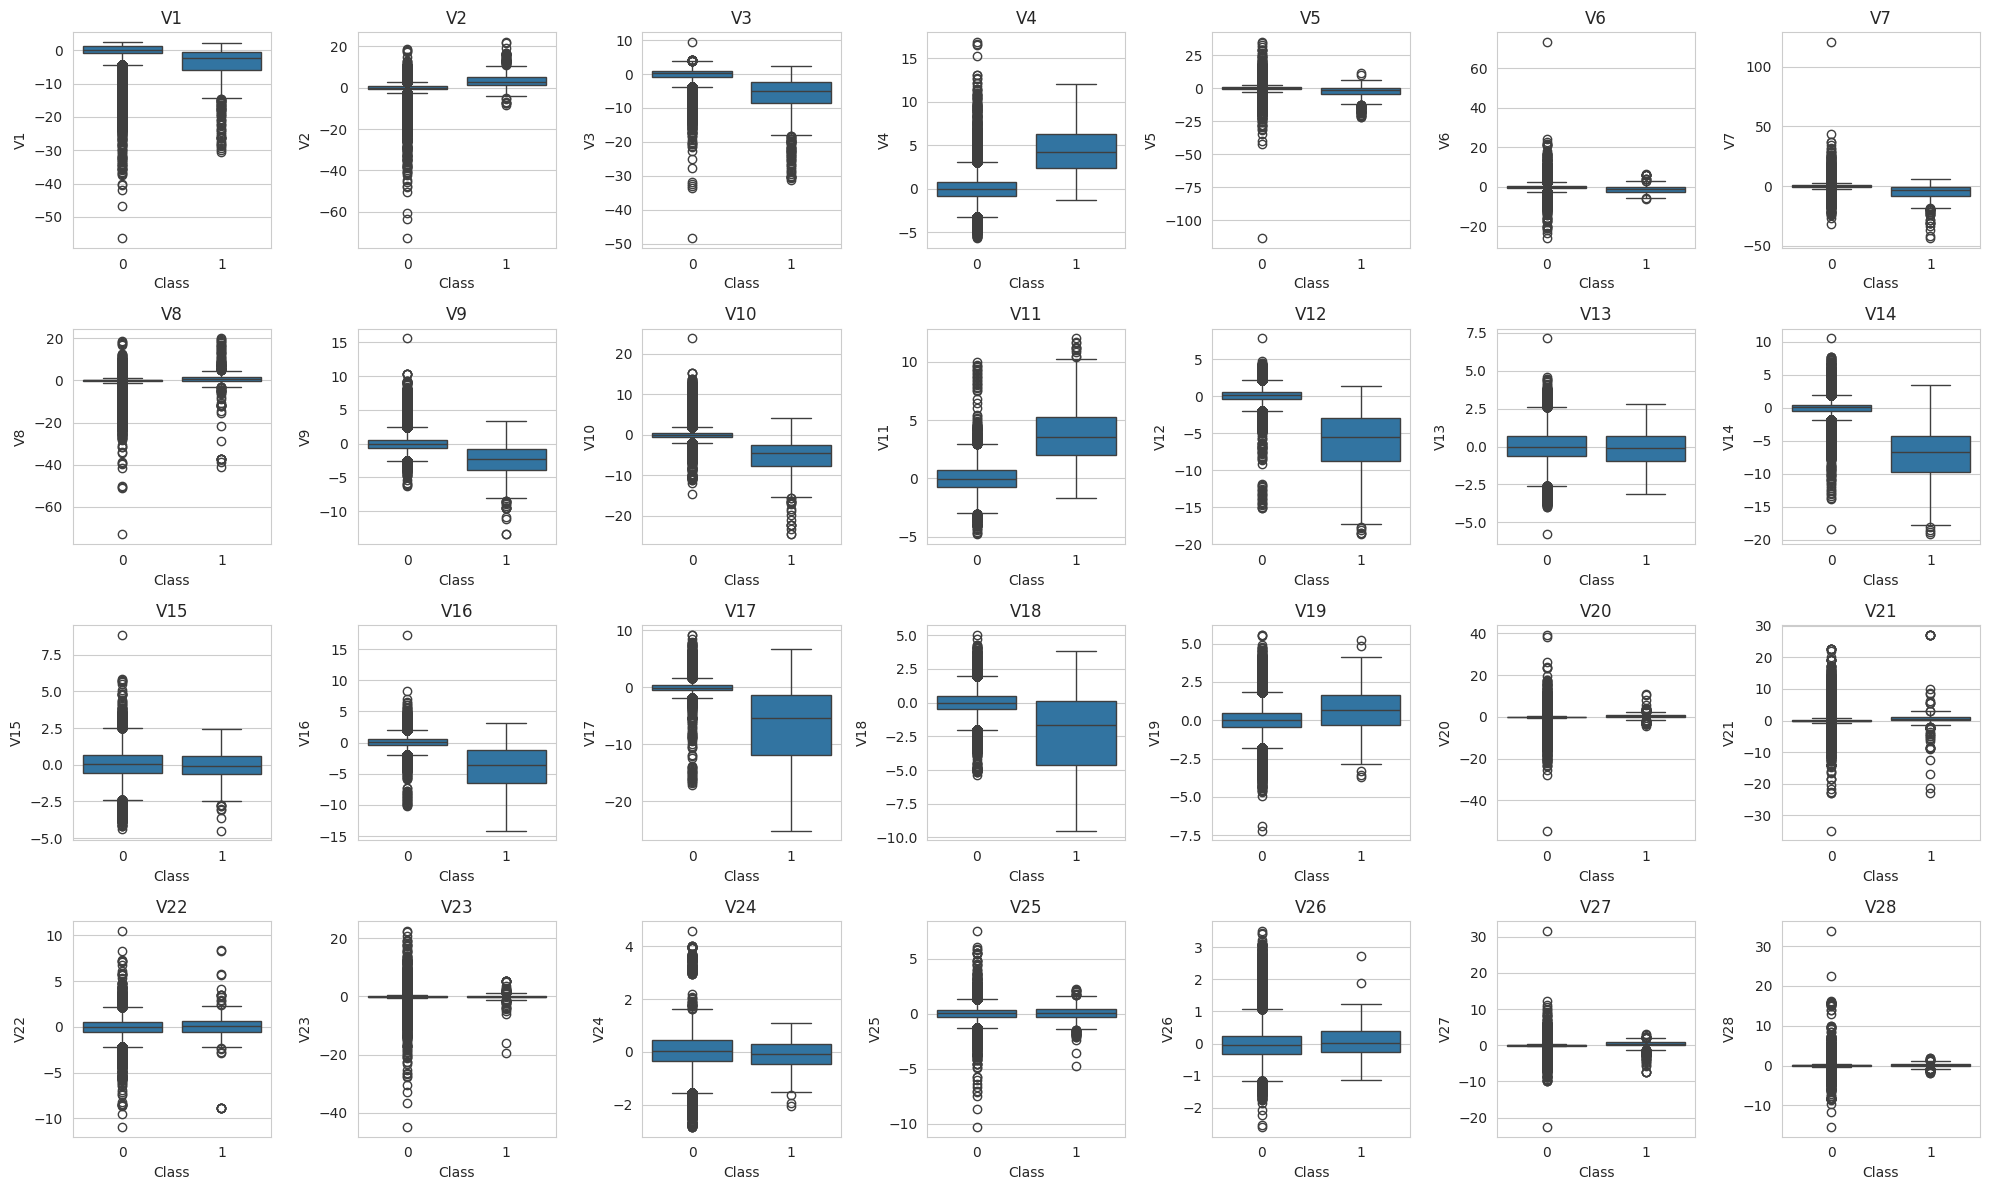

In [167]:
fig,axes = plt.subplots(4,7,figsize=(20,12))
for i, ax in enumerate(axes.flat):
    sns.boxplot(x='Class',y=f'V{i+1}',data=df,ax=ax)
    ax.set_title(f'V{i+1}')
    plt.tight_layout()
plt.show()

**6.Correlation Heatmap**

<Axes: >

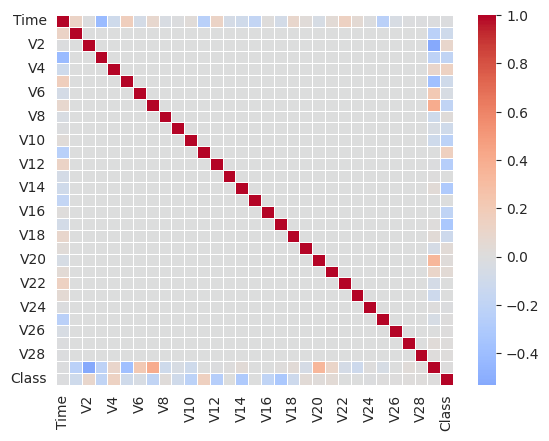

In [168]:
sns.heatmap(df.corr(),cmap='coolwarm',center=0,linewidths=0.5)

**Based on above heatmap, more focused version below which shows only Correlations with the Class Column**

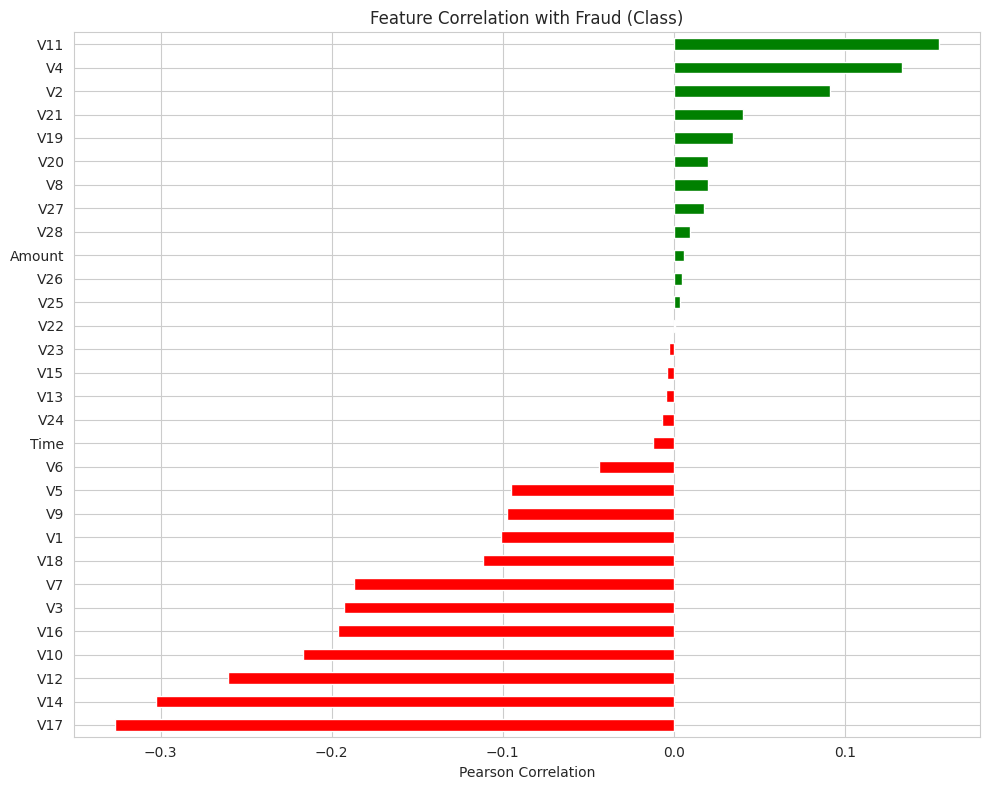

In [169]:
class_corr = df.corr()['Class'].drop('Class').sort_values()
plt.figure(figsize=(10, 8))
class_corr.plot(kind='barh', color=class_corr.map(lambda x: 'red' if x < 0 else 'green'))
plt.title('Feature Correlation with Fraud (Class)')
plt.xlabel('Pearson Correlation')
plt.tight_layout()

**Above correlation heatmap shows V17, V14,V3,V12, V10 are most negatively correlated with fraud**

/tmp/ipykernel_1534/3451325521.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(t0[feature], bw_method=0.5,label="Class = 0")
/tmp/ipykernel_1534/3451325521.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(t1[feature], bw_method=0.5,label="Class = 1")


<Figure size 640x480 with 0 Axes>

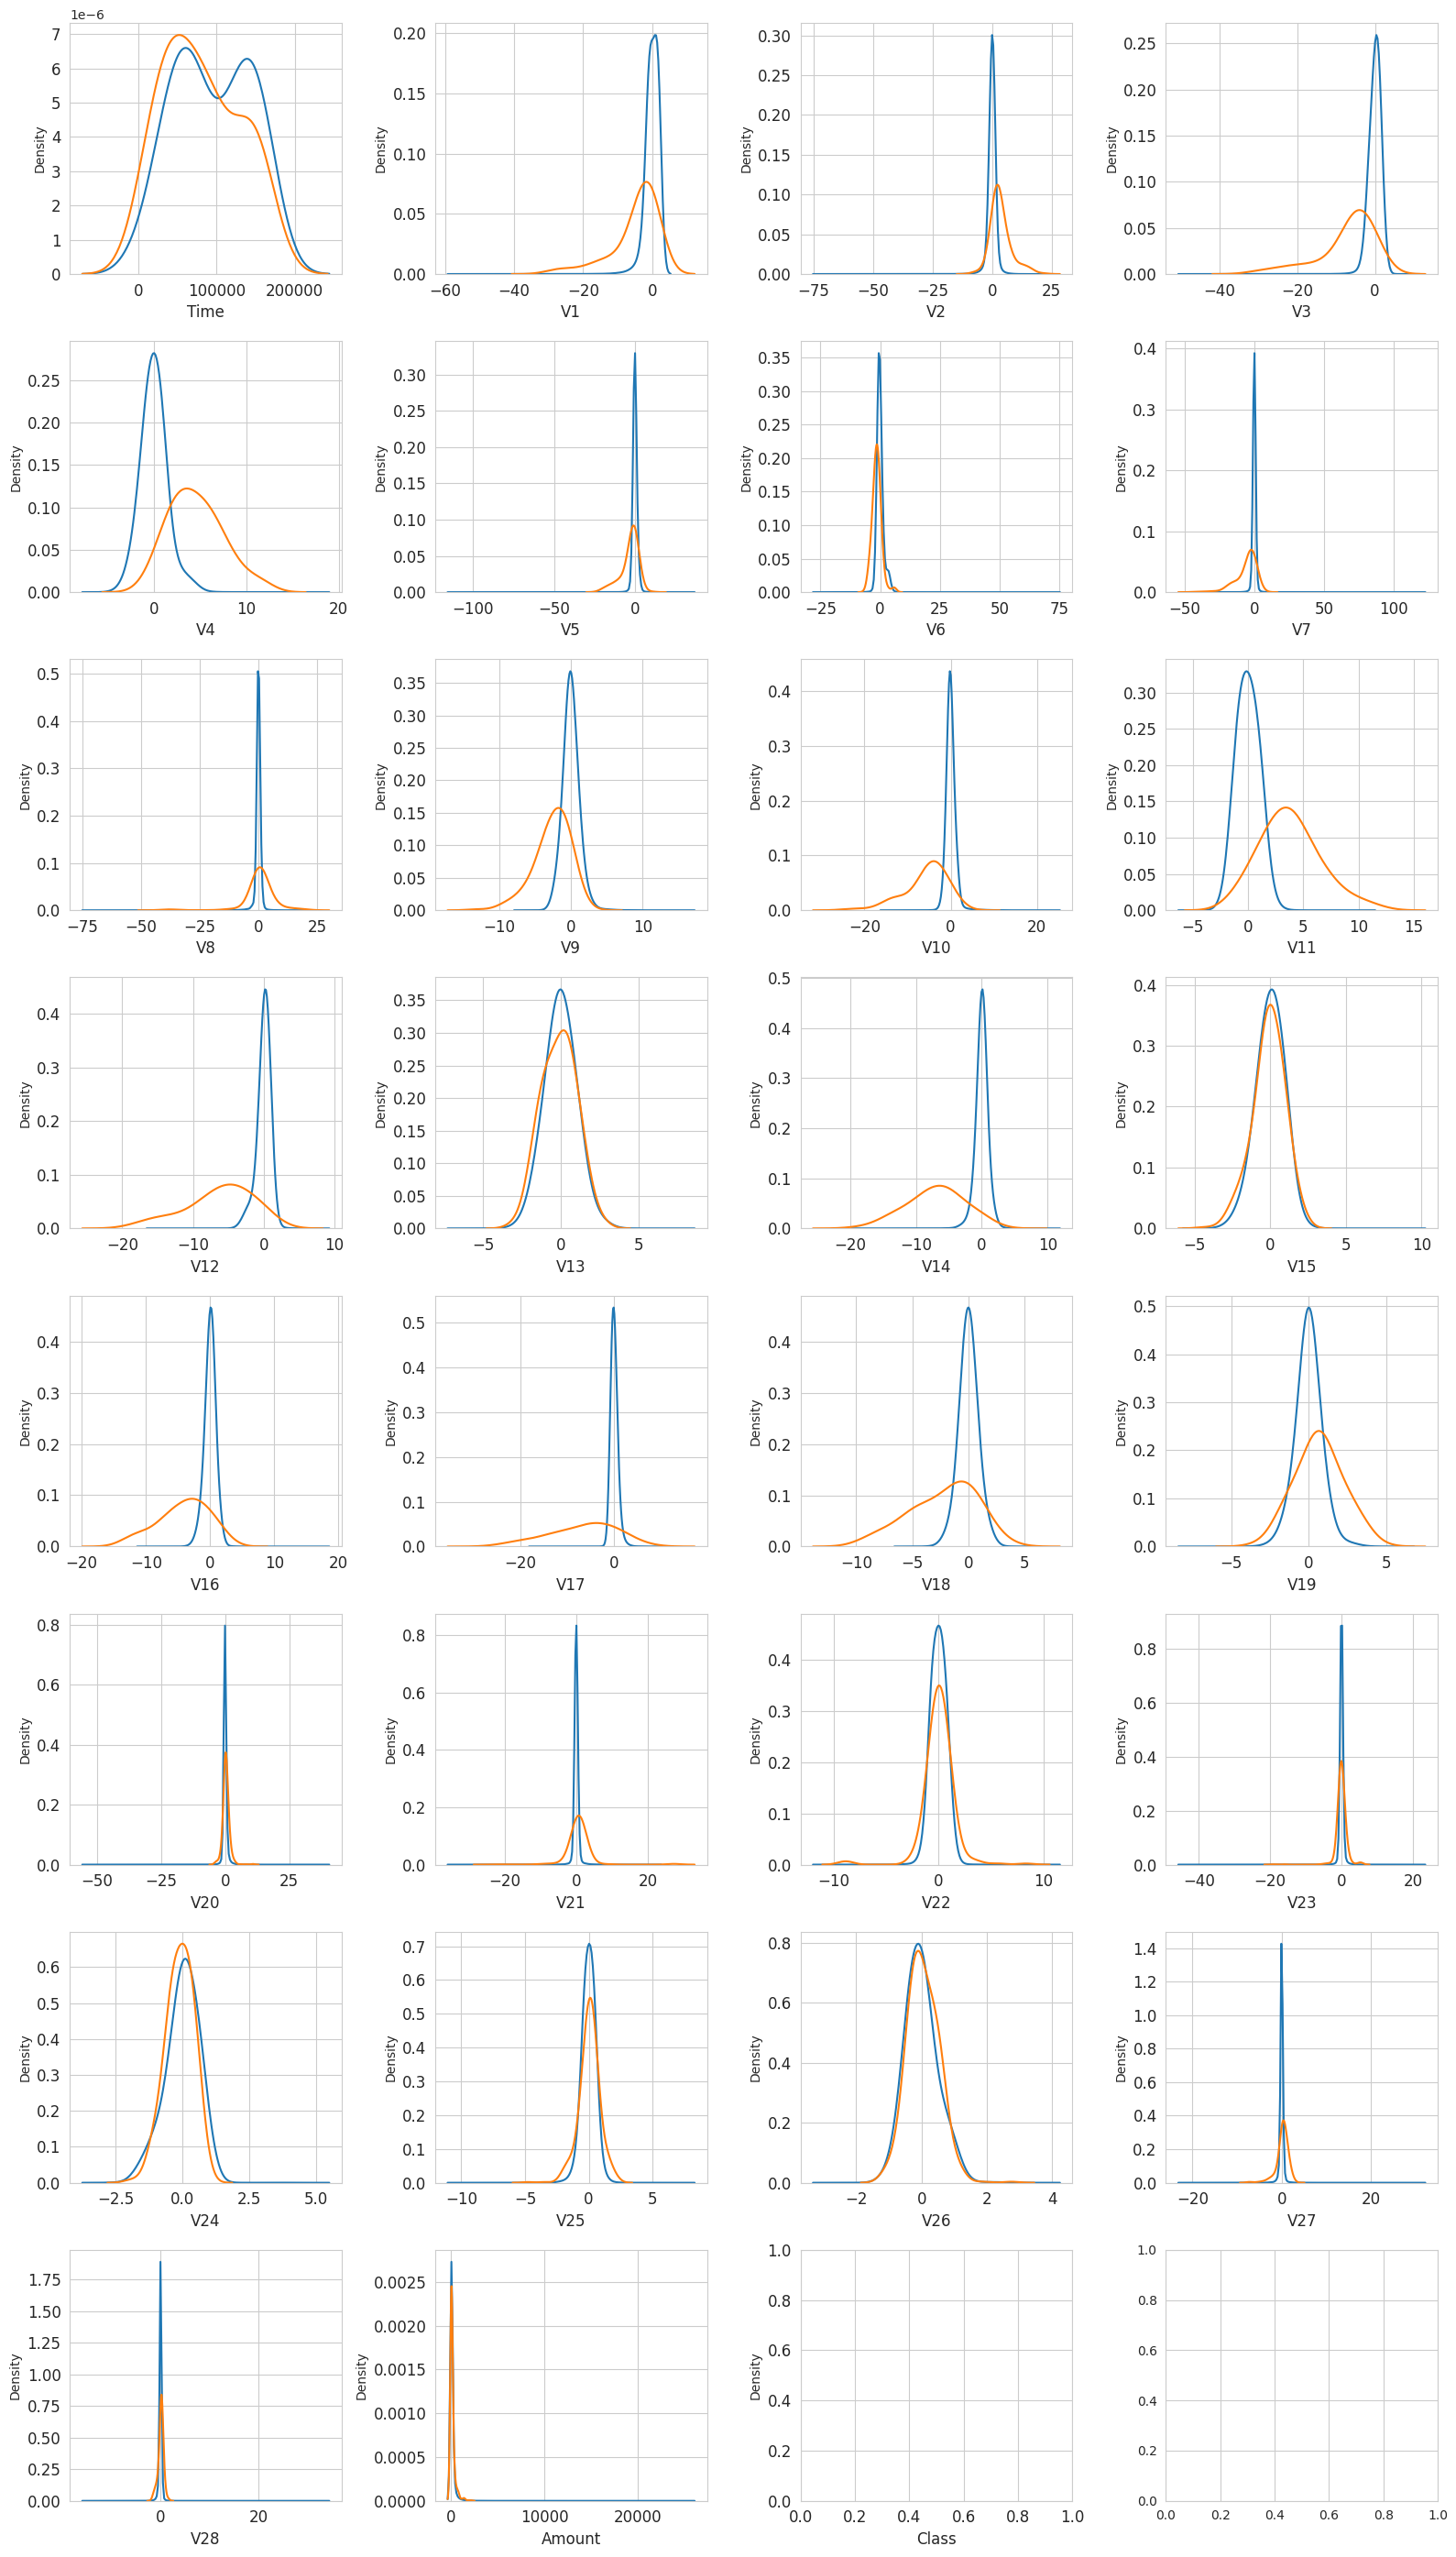

In [170]:
var = df.columns.values

i = 0
t0 = df.loc[df['Class'] == 0]
t1 = df.loc[df['Class'] == 1]

sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(8,4,figsize=(16,28))

for feature in var:
    i += 1
    plt.subplot(8,4,i)
    sns.kdeplot(t0[feature], bw_method=0.5,label="Class = 0")
    sns.kdeplot(t1[feature], bw_method=0.5,label="Class = 1")
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.tight_layout()
plt.show();


**distributions for Class values 0 and 1**
*   Class Values V4 and V11  have clearly separated
*   V12, V14, V18 are partially separated
*   V1, V2, V3, V10 have distinct profile
*   V25, V26, V28 have similar profiles







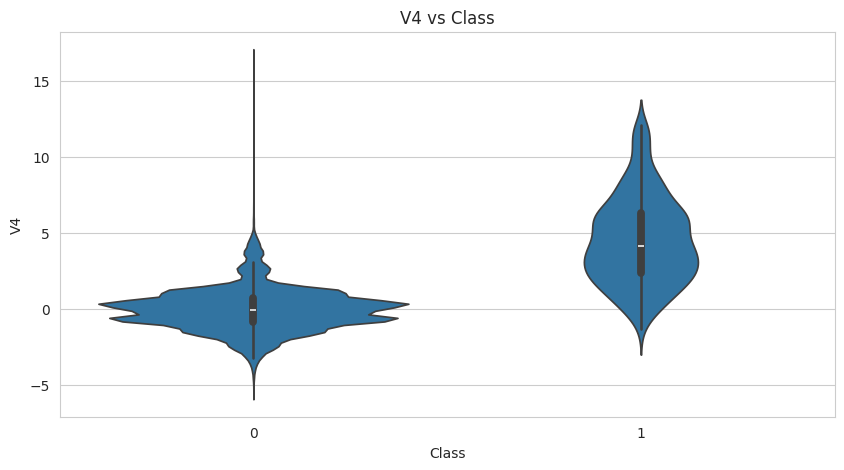

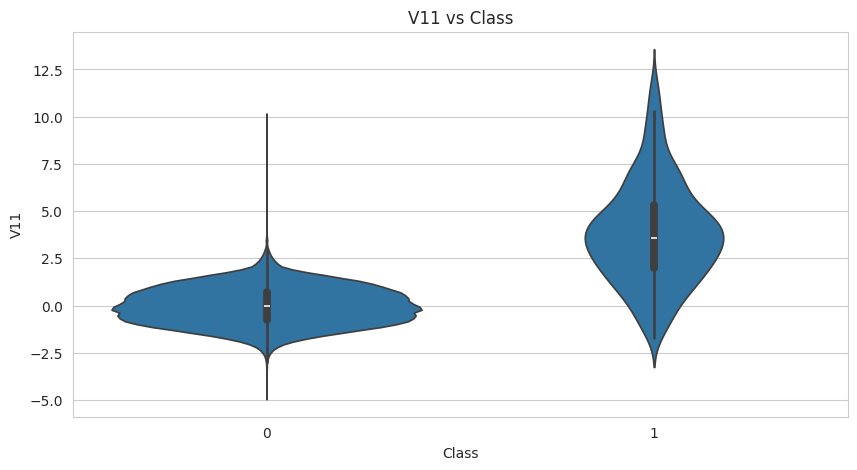

In [171]:
#violin plot
#based on step #5 - top features are V4,V11
t_features=['V4','V11']
for col in t_features:
    plt.figure(figsize=(10,5))
    sns.violinplot(x='Class',y=col,data=df)
    plt.title(f'{col} vs Class')
    plt.show()

<Axes: title={'center': 'Log Amount'}, ylabel='Frequency'>

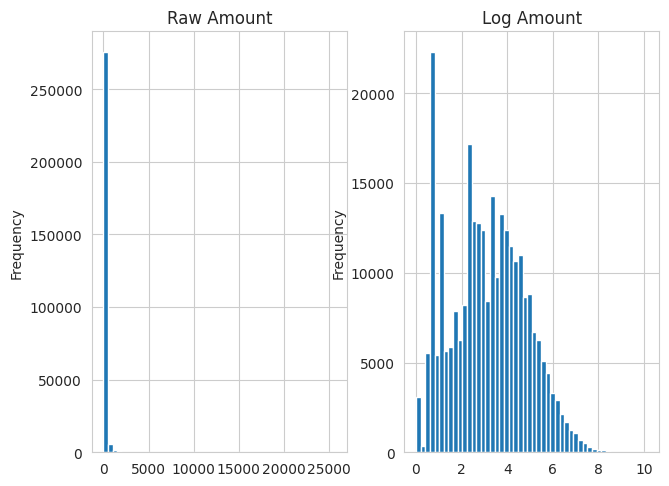

In [172]:
fig,axes = plt.subplots(1,2)
plt.tight_layout()
df['Amount'].plot(kind='hist',bins=50,ax=axes[0],title='Raw Amount')
np.log1p(df['Amount']).plot(kind='hist',bins=50,ax=axes[1],title='Log Amount')

# ============================================================
# Data Preparation and Modeling
# ============================================================

# - Handle class imbalance (class_weight='balanced')
# - Scale Amount with StandardScaler
# - Time-based train/test split (no future leakage)

Collect all meterics in an array to display at the end.

In [173]:
from sklearn.metrics import roc_auc_score,average_precision_score, accuracy_score, precision_score, recall_score, f1_score
results=[]
def save_metrics(name,y_test,y_pred,y_proba):
  results.append({
      'Model': name, # Changed key to string for easier DataFrame creation
      'ROC-AUC' :roc_auc_score(y_test,y_pred),
      'PR-AUC':average_precision_score(y_test,y_proba),
      'Accuracy':accuracy_score(y_test,y_pred),
      'Precision':precision_score(y_test,y_pred),
      'Recall':recall_score(y_test,y_pred),
      'F1-Score':f1_score(y_test,y_pred)
  })

In [174]:


def Plot_Feature_Importance(model,name):
  feature_importances = None
  feature_names = X_train.columns

  if hasattr(model, 'feature_importances_'):
      feature_importances = model.feature_importances_
  elif isinstance(model, Pipeline) and hasattr(model.named_steps['model'], 'coef_'):
      feature_importances = np.abs(model.named_steps['model'].coef_[0]) # Use absolute coefficients for linear models
  # For DummyClassifier and other models without importances/coefficients, feature_importances remains None

  if feature_importances is not None:
      tmp = pd.DataFrame({'Feature': feature_names, 'Feature importance': feature_importances})
      tmp = tmp.sort_values(by='Feature importance',ascending=False)
      plt.figure(figsize = (7,4))
      plt.title(f'Feature Importance for : {name}',fontsize=14)
      s = sns.barplot(x='Feature',y='Feature importance',data=tmp)
      s.set_xticklabels(s.get_xticklabels(),rotation=90)
      plt.show()

      cm = pd.crosstab(y_test.values, y_pred, rownames=['Actual'], colnames=['Predicted'])
      fig, (ax1) = plt.subplots(ncols=1, figsize=(5,5))
      sns.heatmap(cm,
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            annot=True,ax=ax1,
            linewidths=.2,linecolor="Darkblue", cmap="Blues")
      plt.title(f'Confusion Matrix For : {name}', fontsize=14)
      plt.show()

# **Dummy Baseline Classifier**

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



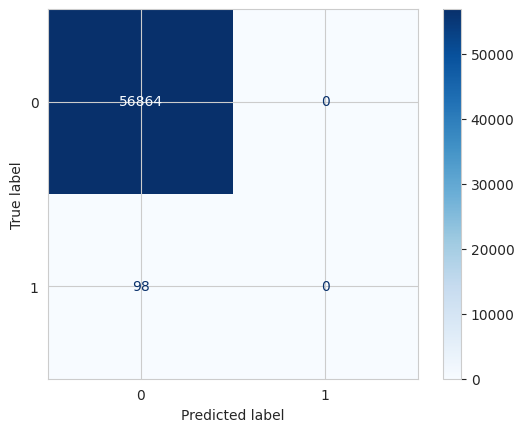

In [175]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier # Added this import statement

X= df.drop('Class',axis=1)
y= df['Class']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2018,stratify=y,shuffle=True)
#Dummy always predicts "not fraud"
Dummy = DummyClassifier(strategy='most_frequent')
Dummy.fit(X_train,y_train)
dummy_y_pred = Dummy.predict(X_test)
print (metrics.classification_report(y_test,dummy_y_pred))
ConfusionMatrixDisplay.from_predictions(y_test,dummy_y_pred,cmap='Blues')
save_metrics('Dummy',y_test,dummy_y_pred,Dummy.predict_proba(X_test)[:,1])
Plot_Feature_Importance(Dummy,'Dummy')

# Logistic Regression

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.91      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962



/tmp/ipykernel_1534/1904158431.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


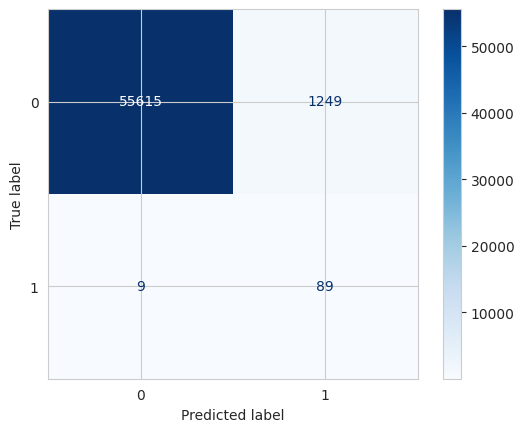

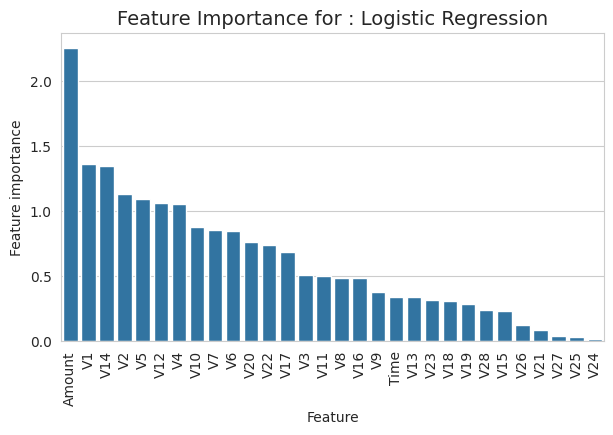

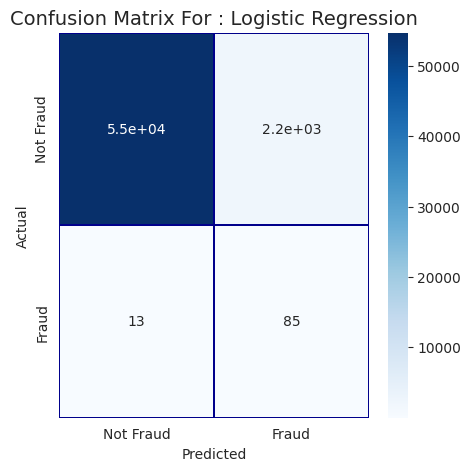

In [176]:


lrg = Pipeline([('scaler',StandardScaler()),('model',LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000))])
lrg.fit(X_train,y_train)

#print(X_test.isnull().sum())
lrg_y_pred = lrg.predict(X_test)
print (metrics.classification_report(y_test,lrg_y_pred))
ConfusionMatrixDisplay.from_predictions(y_test,lrg_y_pred,cmap='Blues')
save_metrics('Logistic Regression',y_test,lrg_y_pred,lrg.predict_proba(X_test)[:,1])
Plot_Feature_Importance(lrg,'Logistic Regression')

**Precision - Recall Curve (Due to imbalanced Data**)

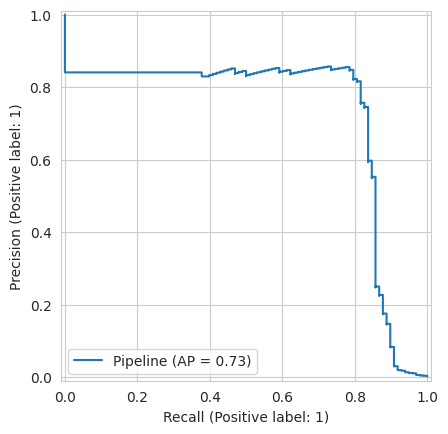

In [177]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(lrg,X_test,y_test)

# **LightGBM**

Training until validation scores don't improve for 50 rounds
[100]	valid_0's average_precision: 0.793042	valid_0's binary_logloss: 0.00527685
[200]	valid_0's average_precision: 0.817468	valid_0's binary_logloss: 0.00364191
[300]	valid_0's average_precision: 0.831946	valid_0's binary_logloss: 0.003267
[400]	valid_0's average_precision: 0.838495	valid_0's binary_logloss: 0.00316592
[500]	valid_0's average_precision: 0.844806	valid_0's binary_logloss: 0.00314535
Early stopping, best iteration is:
[472]	valid_0's average_precision: 0.843698	valid_0's binary_logloss: 0.00314304
Best iteration: 472
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



/tmp/ipykernel_1534/1904158431.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


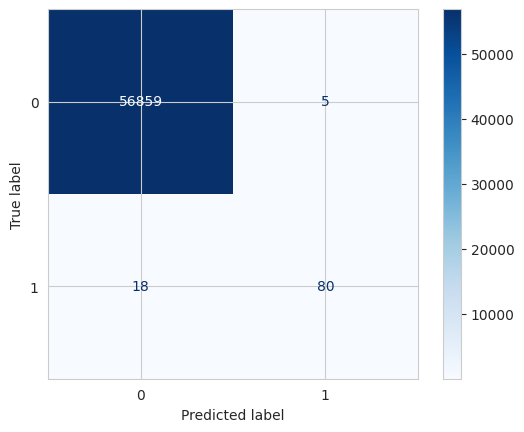

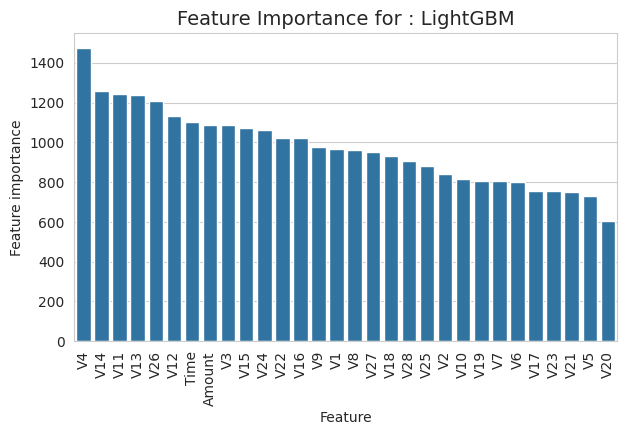

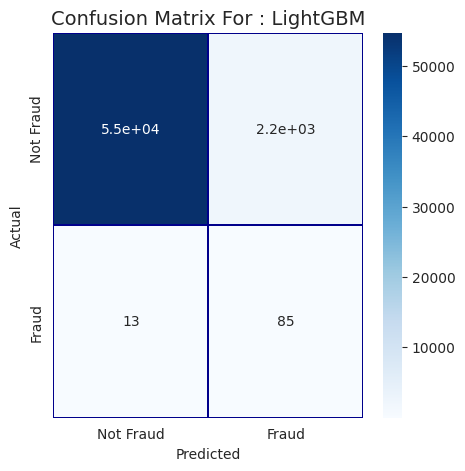

In [178]:
lgb_model = lgb.LGBMClassifier(
    scale_pos_weight  = scale,
    boosting_type     = 'gbdt',
    objective         = 'binary',
    num_leaves        = 63,
    max_depth         = -1,
    n_estimators      = 2000,          # set high — early stopping will cut it
    learning_rate     = 0.02,          # slower learning = better generalization
    subsample         = 0.8,
    subsample_freq    = 1,
    colsample_bytree  = 0.7,
    min_child_samples = 20,
    min_child_weight  = 1e-3,
    reg_alpha         = 0.1,           # L1 regularization — new, helps precision
    reg_lambda        = 1.0,           # L2 regularization — new, prevents overfit
    max_bin           = 255,
    n_jobs            = -1,
    verbose           = -1,
    random_state      = 42
)

# Fit with early stopping
lgb_model.fit(
    X_train, y_train,
    eval_set              = [(X_test, y_test)],
    eval_metric           = 'average_precision',
    callbacks             = [lgb.early_stopping(stopping_rounds=50),
                             lgb.log_evaluation(100)]
)

print(f"Best iteration: {lgb_model.best_iteration_}")

lgb_y_pred = lgb_model.predict(X_test)
print (metrics.classification_report(y_test,lgb_y_pred))
ConfusionMatrixDisplay.from_predictions(y_test,lgb_y_pred,cmap='Blues')
save_metrics('LightGBM',y_test,lgb_y_pred,lgb_model.predict(X_test))
Plot_Feature_Importance(lgb_model,'LightGBM')

# **Random Forest**

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.79      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



/tmp/ipykernel_1534/1904158431.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


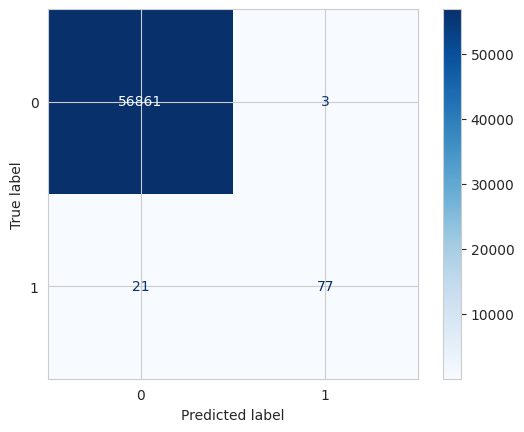

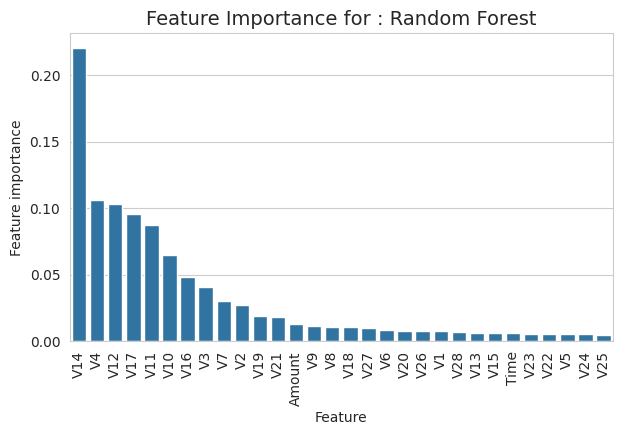

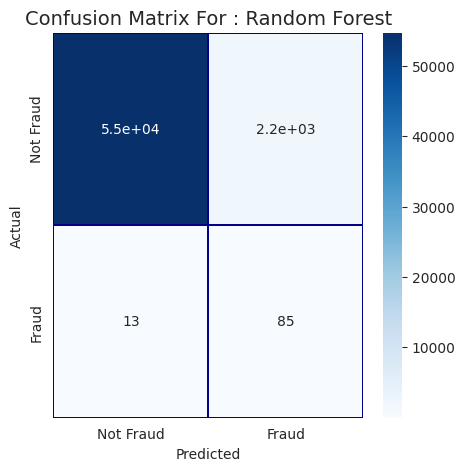

In [179]:
from sklearn.ensemble import RandomForestClassifier
RFC = RandomForestClassifier(class_weight='balanced',n_estimators=100,n_jobs=4,criterion='gini',verbose=False)
RFC.fit(X_train,y_train)
RFC_y_pred = RFC.predict(X_test)
print (metrics.classification_report(y_test,RFC_y_pred))
ConfusionMatrixDisplay.from_predictions(y_test,RFC_y_pred,cmap='Blues')
save_metrics('Random Forest',y_test,RFC_y_pred,RFC.predict_proba(X_test)[:,1])
Plot_Feature_Importance(RFC,'Random Forest')

# **AdaBoostClassifier**

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.69      0.74        98

    accuracy                           1.00     56962
   macro avg       0.90      0.85      0.87     56962
weighted avg       1.00      1.00      1.00     56962



/tmp/ipykernel_1534/1904158431.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


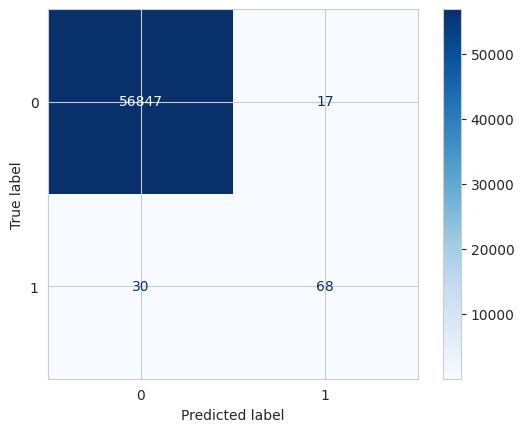

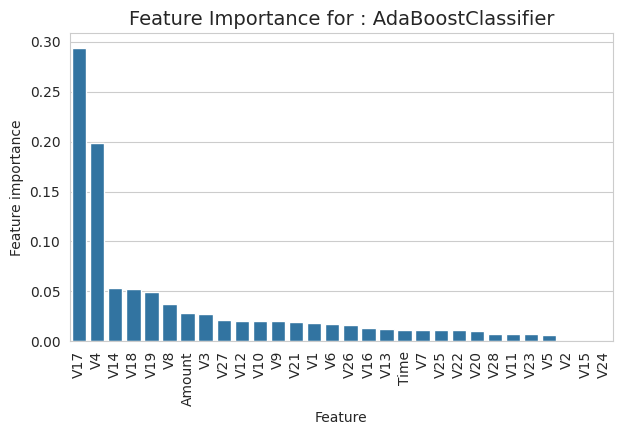

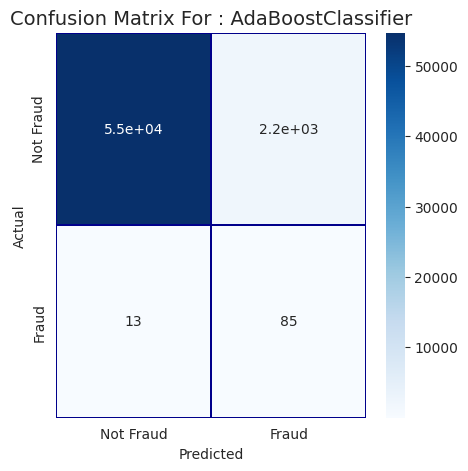

In [180]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME', learning_rate=0.8)
model.fit(X_train, y_train)
abc_y_pred = model.predict(X_test)
print (metrics.classification_report(y_test,abc_y_pred))
ConfusionMatrixDisplay.from_predictions(y_test,abc_y_pred,cmap='Blues')
Plot_Feature_Importance(model,'AdaBoostClassifier')
save_metrics('AdaBoostClassifier',y_test,abc_y_pred,model.predict_proba(X_test)[:,1])


              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.87      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.91      0.53     56962
weighted avg       1.00      0.96      0.98     56962



/tmp/ipykernel_1534/1904158431.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


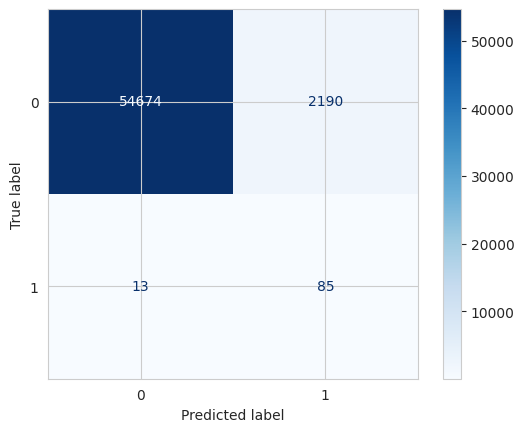

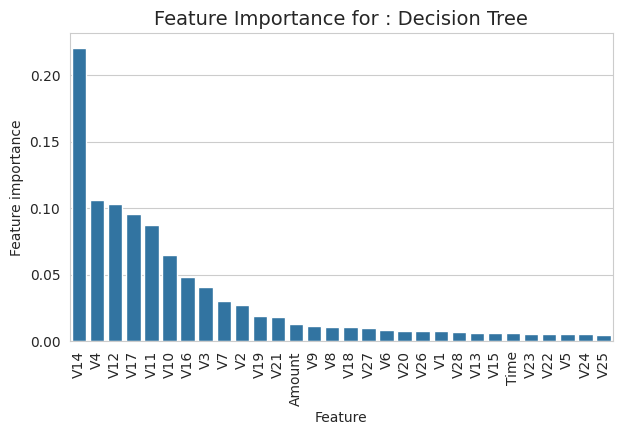

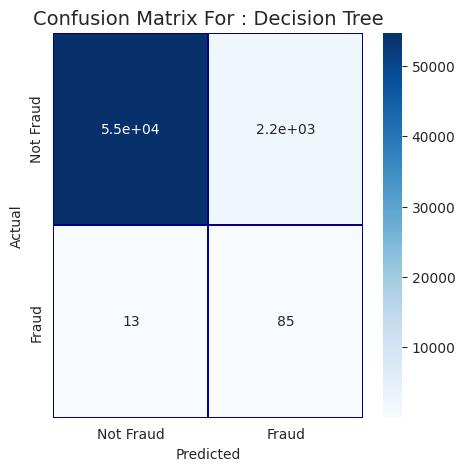

In [181]:
from sklearn.tree import DecisionTreeClassifier
DTC = DecisionTreeClassifier(class_weight='balanced',max_depth=6)
DTC.fit(X_train,y_train)
DTC_y_pred = DTC.predict(X_test)
print (metrics.classification_report(y_test,DTC_y_pred))
ConfusionMatrixDisplay.from_predictions(y_test,DTC_y_pred,cmap='Blues')
save_metrics('Decision Tree',y_test,DTC_y_pred,DTC.predict_proba(X_test)[:,1])
Plot_Feature_Importance(RFC,'Decision Tree')

In [182]:
from IPython.display import display
results_df = pd.DataFrame(results).sort_values('ROC-AUC',ascending=False)

display(results_df)

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1-Score
1,Logistic Regression,0.943099,0.725021,0.977915,0.066517,0.908163,0.123955
5,Decision Tree,0.914417,0.534880,0.961325,0.037363,0.867347,0.071639
2,LightGBM,0.908119,0.768623,0.999596,0.941176,0.816327,0.874317
3,Random Forest,0.892831,0.861874,0.999579,0.962500,0.785714,0.865169
4,AdaBoostClassifier,0.846789,0.757589,0.999175,0.800000,0.693878,0.743169
0,Dummy,0.500000,0.001720,0.998280,0.000000,0.000000,0.000000


# Classification Metrics used for analysis (some details)
**Accuracy:** The overall percentage of correct predictions.

**Precision:** The proportion of positive predictions that were actually correct.

**Recall (Sensitivity):** The proportion of actual positive cases that the model correctly identified.

**F1-Score:** The harmonic mean of precision and recall, used to find a balance between the two.

**Confusion Matrix:** A table summarizing true positives, true negatives, false positives, and false negatives.

**AUC-ROC:** A curve that visualizes the model's ability to distinguish between classes at various thresholds.

**PR-AUC:** This is most important for this case as it is a performance metric used in binary classification to evaluate how well a model balances precision and recall. It is particularly effective for **imbalanced datasets** where the positive (minority) class is the primary focus,

## **Analysis**
**Dummy:** Predicts nothing as fraud. Accuracy looks great at 99.83% — which is exactly why accuracy is useless here. Catches zero fraud. Everything else must beat this.

**Logistic Regression:** This is the **most deceptive** row in the table. Highest ROC-AUC of all models — but PR-AUC is nearly as low as the Dummy. High recall (0.908) means it catches 90% of fraud — but precision of 0.067 means for every 1 real fraud it catches, it falsely flags 14 innocent transactions. This is risk as too many false alarms will be seen in prod.

**Decision Tree:** Decision Tree has **worse performance**than Logistic Regression. It catches fraud but flags 1 in 27 legit transactions as fraud. Hence Decision Tree not usable in this case.

***Both Logistic Regression and Decision Tree are Accuracy Trap***

**AdaBoostClassifier:** is a "**middle-of-the-pack**" performer. It is significantly better than the basic Logistic Regression and Decision Tree models for this task, but it doesn't quite reach the performance level of the top-tier models

**LightGBM :** has the highest F1-Score (0.874), indicating it has the best balance between catching positive cases (Recall) and being correct when it does (Precision).

**Random Forest:** is a close second. It is slightly more "conservative" than LightGBM (higher precision, lower recall), meaning it’s very reliable when it predicts a positive, but misses a few more than LightGBM

# **Conclusion:**
For current Dataset, **LightGBM and Random Forest** are best performer/ Winners: with Mean Accuracy of 0.996 -Excellent Performance and range 0.00014 which shows high reliability , LightGBM shows it is highly stable (low variance) across all folds( however class imbalance , data leak and overfitting should be checked) Precision, Recall and F1 score mitigate some of those risks. A balance of finding as many cases as possible without too many false alarms, LightGBM best. If avoiding "false positives" is priority then, Random Forest is slightly better
